In [14]:
import pandas as pd
import requests

url = 'https://raw.githubusercontent.com/ayushOverfits/finalData/main/final_Data.xlsx'

# Download the file to a local path
local_file_path = '/content/drive/MyDrive/final_Data.xlsx'

# Read the Excel file from the local path
portfolio_data = pd.read_excel(url, index_col=0)
print(portfolio_data.head())

                AAPL   BTC-USD   ETH-USD       GLD      MSFT      NVDA  \
Date                                                                     
2019-01-03 -0.099607 -0.027050 -0.038135  0.009066 -0.036788 -0.060417   
2019-01-04  0.042689  0.005467  0.036523 -0.008086  0.046509  0.064068   
2019-01-07 -0.002226  0.043427 -0.018648  0.003458  0.001276  0.052941   
2019-01-08  0.019063  0.001391 -0.008831 -0.002708  0.007251 -0.024896   
2019-01-09  0.016982  0.001104  0.002949  0.006418  0.014299  0.019667   

                 QQQ       SPY       USO  Market_Regime  
Date                                                     
2019-01-03 -0.032670 -0.023863  0.010152             -1  
2019-01-04  0.042785  0.033496  0.023116             -1  
2019-01-07  0.011906  0.007885  0.010805             -1  
2019-01-08  0.009046  0.009395  0.020408             -1  
2019-01-09  0.008150  0.004674  0.052381             -1  


# Dynamic Regime-Switching Asset Allocation Strategy

This section implements a discrete, state-dependent allocation model. Rather than relying on a static, unconditional covariance matrix ($\Sigma$) and expected return vector ($\mu$), this algorithm assumes that financial markets experience structural breaks, shifting between distinct macroeconomic states (regimes).


### 1. Conditional Asset Allocation via Regime Identification


Let $S_t$ denote the identified market regime at time $t$:

* **$S_t = 1$ (Bull Market):** The capital is allocated to the **Tangency Portfolio (Maximum Sharpe Ratio)** to maximize risk-adjusted returns along the efficient frontier.
* **$S_t = -1$ (Bear Market):** The objective function shifts to the **Global Minimum Variance (GMV)** portfolio, actively minimizing portfolio volatility and rotating exposure into uncorrelated safe-haven assets.

### 2. Algorithmic State-Transition Logic
The strategy constructs a dynamic, time-series matrix of portfolio weights, $W_t$. The allocation strictly follows conditional logic based on the continuous monitoring of the underlying regime indicator:

$$
W_t = \begin{cases}
W_{\text{MaxSharpe}} & \text{if } S_t = 1 \\
W_{\text{MinVol}} & \text{if } S_t = -1
\end{cases}
$$

This creates an active, rules-based hedging mechanism that structurally reduces portfolio beta during periods of elevated systemic risk.

### 3. Information Lag and Look-Ahead Bias Mitigation
A critical constraint in backtesting quantitative models is the strict adherence to chronological information flow to prevent **look-ahead bias**.

The regime state $S_t$ is calculated using closing price data at time $t$. Therefore, the signal is only observable after the trading session concludes. By applying a one-period temporal lag (`shift(1)`), the model enforces the constraint that the optimal weights applied to the returns at time $t+1$ are strictly a function of the information set available at time $t$ ($\Omega_t$).

Mathematically, the realized portfolio return is calculated as:

$$
R_{\text{portfolio}, t+1} = \sum_{i=1}^{N} (w_{i,t} \cdot R_{i, t+1})
$$

This simple temporal shift guarantees the out-of-sample validity of the backtest.

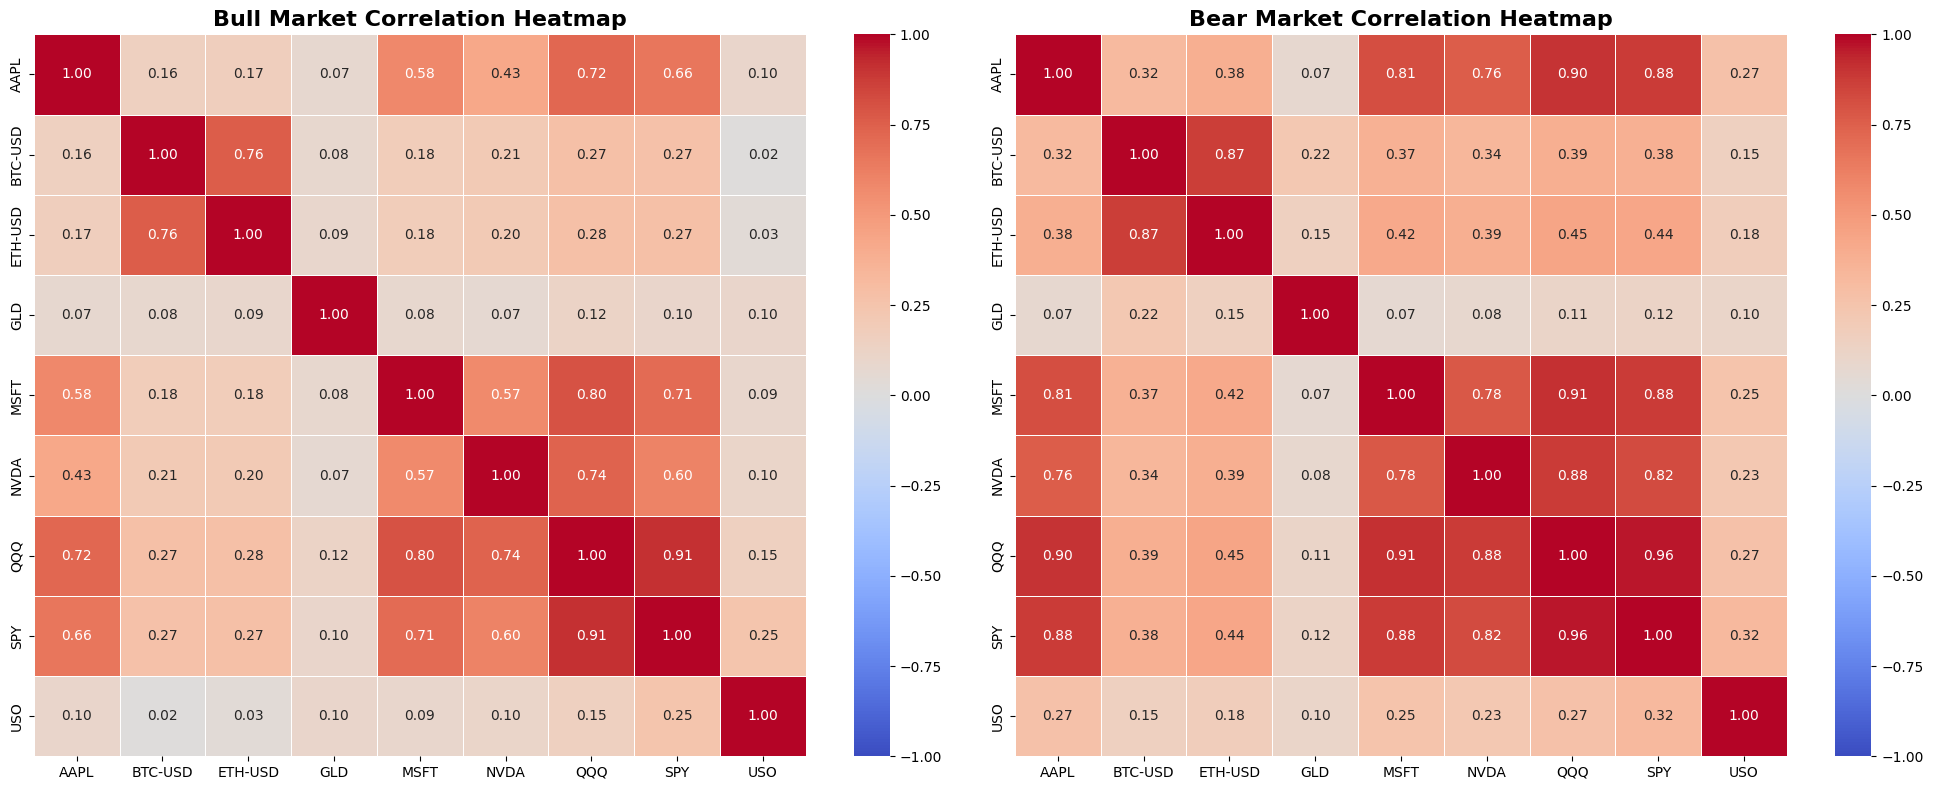

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Separate the data into Bull and Bear regimes, then drop the regime label
bull_returns = portfolio_data[portfolio_data['Market_Regime'] == 1].drop(columns=['Market_Regime'])
bear_returns = portfolio_data[portfolio_data['Market_Regime'] == -1].drop(columns=['Market_Regime'])

# 2. Calculate the exact correlation between assets for both regimes
correlation_bull = bull_returns.corr()
correlation_bear = bear_returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
# 4. Bull Market Heatmap
sns.heatmap(correlation_bull, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5, ax=axes[0])
axes[0].set_title("Bull Market Correlation Heatmap", fontsize=16, fontweight='bold')

# 5.Bear Market Heatmap
sns.heatmap(correlation_bear,annot=True,cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5, ax=axes[1])
axes[1].set_title("Bear Market Correlation Heatmap", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Inferences from the heat maps:
##Cross-Asset Correlation Analysis
The correlation heatmap quantifies the historical linear relationships between the selected assets on a scale of -1.0 to 1.0. Analyzing these relationships is a critical prerequisite for Mean-Variance Optimization, as portfolio risk reduction relies on combining assets with low or negative correlations.
1. <b>The Contagion Effect (Systemic Risk)</b><br>
The Observation: When comparing the left map (Bull) to the right map (Bear), you will generally see the Bear map become significantly more "red" (closer to 1.0) across the equity and index blocks.<br>The Inference: In a normal, upward-trending market, assets trade based on their individual fundamentals. However, during a severe market drawdown (Bear regime), panic selling ensues. Investors liquidate positions across the board to raise cash, causing normally distinct assets to crash in unison. This visually proves the quantitative adage: "In a crisis, all correlations approach 1.0."

2. <b>The Reality of Digital Assets (Crypto is Risk-On)</b><br>The Observation: Look specifically at the intersection of BTC-USD or ETH-USD against traditional market indices like SPY or QQQ. In the Bull market, the correlation might appear moderate (e.g., 0.30 to 0.50). In the Bear market, that correlation typically spikes much higher.<br>The Inference: Cryptocurrency is frequently marketed as an uncorrelated "hedge" against the traditional financial system. Your regime-specific heatmaps mathematically disprove this for severe stress events. During panic scenarios, crypto behaves identically to a high-beta technology stock. It does not protect the portfolio during a crash; it actively accelerates the drawdown.

3. <b>Identifying True "Safe Havens"</b><br>The Observation: Look at the row and column for Gold (GLD). In the Bull market, its correlation to equities is likely near zero. Crucially, when you look at the Bear market map, Gold's correlation to equities likely remains near zero, or may even turn slightly negative (blue).<br>The Inference: This proves why Gold is a structural necessity in a robust portfolio. While equities and crypto are experiencing contagion and crashing together, Gold retains its statistical independence. It acts as a true shock-absorber.

Simulating 20,000 portfolios for the Bull Market
Simulating 20,000 portfolios for the Bear Market


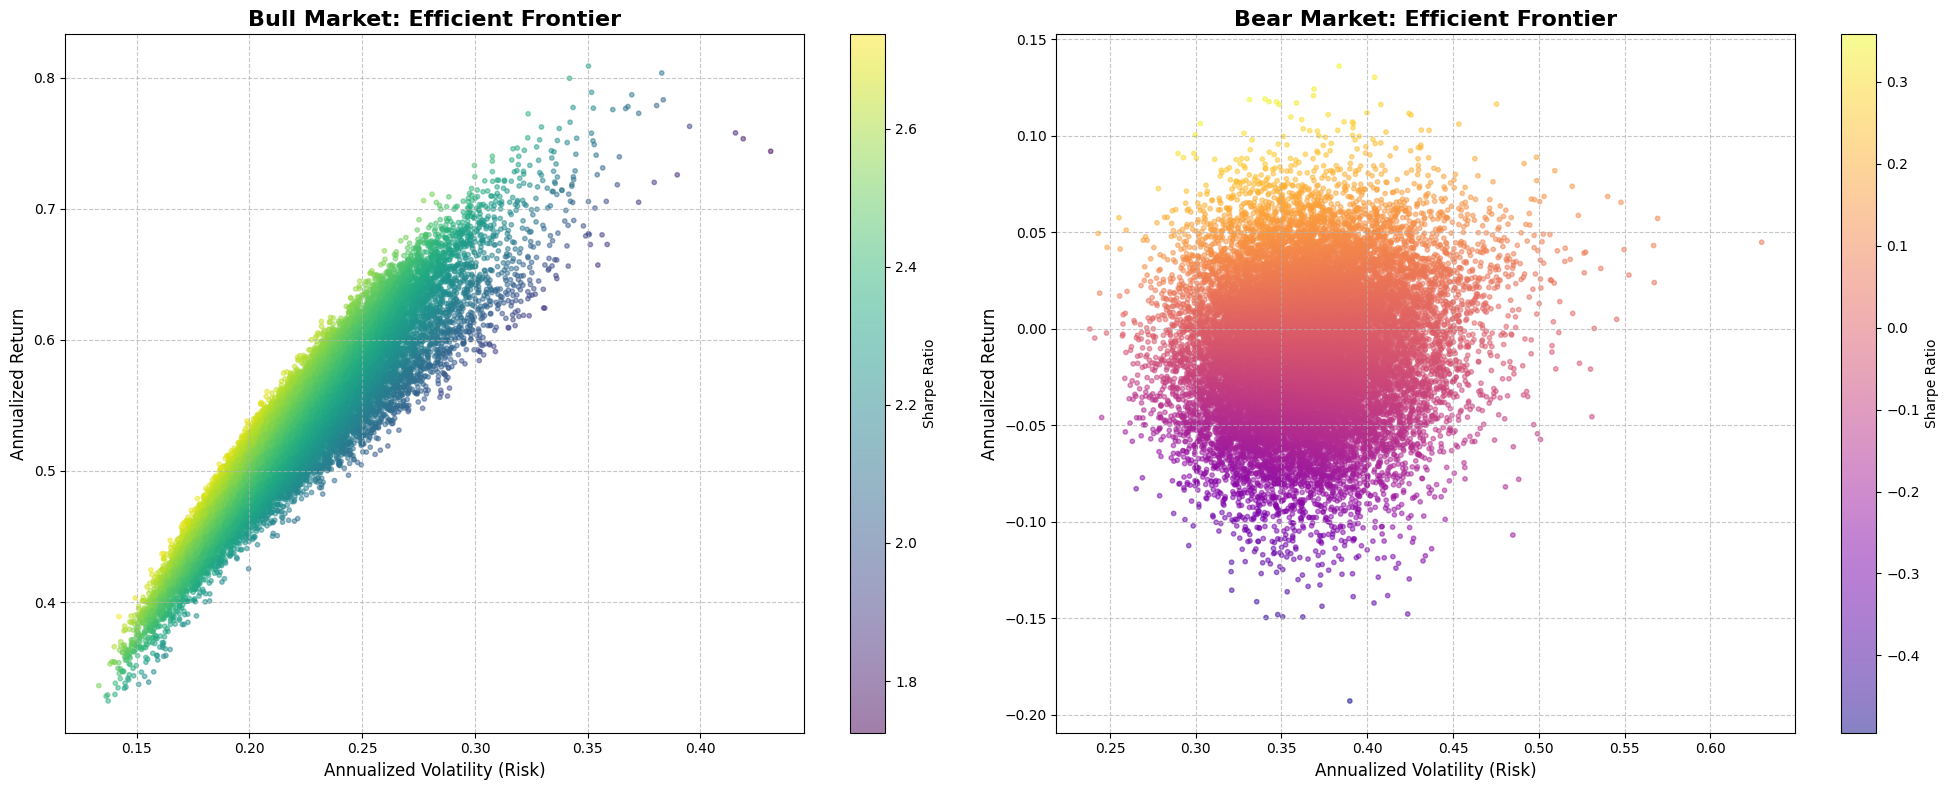

In [16]:
import numpy as np
import matplotlib.pyplot as plt

num_assets = len(bull_returns.columns)
num_portfolios = 20000

# 2. Building a Monte Carlo function
def run_monte_carlo(data):
    # Annualize returns and risk for this specific dataset
    mean_returns = data.mean() * 252
    cov_matrix = data.cov() * 252

    results = np.zeros((3, num_portfolios))
    weights_record = []

    for i in range(num_portfolios):
        # Generate random weights summing to 1.0
        weights = np.random.random(num_assets)
        weights /= np.sum(weights)
        weights_record.append(weights)

        # Calculate Return, Volatility, and Sharpe
        portfolio_return = np.sum(weights * mean_returns)
        portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        sharpe_ratio = portfolio_return / portfolio_std_dev

        # Store results
        results[0,i] = portfolio_return
        results[1,i] = portfolio_std_dev
        results[2,i] = sharpe_ratio

    return results, weights_record

# 3. Run engines
print("Simulating 20,000 portfolios for the Bull Market")
bull_results, bull_weights = run_monte_carlo(bull_returns)

print("Simulating 20,000 portfolios for the Bear Market")
bear_results, bear_weights = run_monte_carlo(bear_returns)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Bull Market Frontier
sc_bull = axes[0].scatter(bull_results[1,:], bull_results[0,:], c=bull_results[2,:], cmap='viridis', marker='o', s=10, alpha=0.5)
fig.colorbar(sc_bull, ax=axes[0], label='Sharpe Ratio')
axes[0].set_title('Bull Market: Efficient Frontier', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Annualized Volatility (Risk)', fontsize=12)
axes[0].set_ylabel('Annualized Return', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Bear Market Frontier
sc_bear = axes[1].scatter(bear_results[1,:], bear_results[0,:], c=bear_results[2,:], cmap='plasma', marker='o', s=10, alpha=0.5)
fig.colorbar(sc_bear, ax=axes[1], label='Sharpe Ratio')
axes[1].set_title('Bear Market: Efficient Frontier', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Annualized Volatility (Risk)', fontsize=12)
axes[1].set_ylabel('Annualized Return', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
import numpy as np

# Bull: Max Sharpe
bull_max_sharpe_idx = np.argmax(bull_results[2])
bull_ms_return = bull_results[0, bull_max_sharpe_idx]
bull_ms_volatility = bull_results[1, bull_max_sharpe_idx]
bull_ms_ratio = bull_results[2, bull_max_sharpe_idx]
bull_ms_weights = bull_weights[bull_max_sharpe_idx]

# Bull: Min Volatility
bull_min_vol_idx = np.argmin(bull_results[1])
bull_mv_return = bull_results[0, bull_min_vol_idx]
bull_mv_volatility = bull_results[1, bull_min_vol_idx]
bull_mv_ratio = bull_results[2, bull_min_vol_idx]
bull_mv_weights = bull_weights[bull_min_vol_idx]

# Bear: Max Sharpe
bear_max_sharpe_idx = np.argmax(bear_results[2])
bear_ms_return = bear_results[0, bear_max_sharpe_idx]
bear_ms_volatility = bear_results[1, bear_max_sharpe_idx]
bear_ms_ratio = bear_results[2, bear_max_sharpe_idx]
bear_ms_weights = bear_weights[bear_max_sharpe_idx]

# Bear: Min Volatility
bear_min_vol_idx = np.argmin(bear_results[1])
bear_mv_return = bear_results[0, bear_min_vol_idx]
bear_mv_volatility = bear_results[1, bear_min_vol_idx]
bear_mv_ratio = bear_results[2, bear_min_vol_idx]
bear_mv_weights = bear_weights[bear_min_vol_idx]


# 3. CREATE READABLE DATAFRAMES
bull_portfolios = pd.DataFrame({
    'Max Sharpe Weight (%)': bull_ms_weights * 100,
    'Min Volatility Weight (%)': bull_mv_weights * 100
}, index=bull_returns.columns).round(2)

bear_portfolios = pd.DataFrame({
    'Max Sharpe Weight (%)': bear_ms_weights * 100,
    'Min Volatility Weight (%)': bear_mv_weights * 100
}, index=bear_returns.columns).round(2)

# 4. PRINT THE FINAL RESUL/-p[0TS
print("==================================================")
print(" BULL MARKET (REGIME 1): THE BEST PORTFOLIOS")
print("==================================================")
print(bull_portfolios)
print("\n--- Bull Market Stats ---")
print(f"Max Sharpe -> Expected Return: {bull_ms_return*100:.2f}%, Risk: {bull_ms_volatility*100:.2f}%, Sharpe: {bull_ms_ratio:.2f}")
print(f"Min Vol    -> Expected Return: {bull_mv_return*100:.2f}%, Risk: {bull_mv_volatility*100:.2f}%, Sharpe: {bull_mv_ratio:.2f}")

print("\n\n==================================================")
print(" BEAR MARKET (REGIME -1): THE BEST PORTFOLIOS")
print("==================================================")
print(bear_portfolios)
print("\n--- Bear Market Stats ---")
print(f"Max Sharpe -> Expected Return: {bear_ms_return*100:.2f}%, Risk: {bear_ms_volatility*100:.2f}%, Sharpe: {bear_ms_ratio:.2f}")
print(f"Min Vol    -> Expected Return: {bear_mv_return*100:.2f}%, Risk: {bear_mv_volatility*100:.2f}%, Sharpe: {bear_mv_ratio:.2f}")

 BULL MARKET (REGIME 1): THE BEST PORTFOLIOS
         Max Sharpe Weight (%)  Min Volatility Weight (%)
AAPL                     15.71                      17.55
BTC-USD                   9.28                       0.48
ETH-USD                   0.15                       1.42
GLD                      36.56                      30.72
MSFT                      0.14                       4.99
NVDA                      8.43                       3.18
QQQ                       1.16                      11.20
SPY                      22.48                      15.75
USO                       6.09                      14.71

--- Bull Market Stats ---
Max Sharpe -> Expected Return: 38.90%, Risk: 14.21%, Sharpe: 2.74
Min Vol    -> Expected Return: 33.63%, Risk: 13.32%, Sharpe: 2.52


 BEAR MARKET (REGIME -1): THE BEST PORTFOLIOS
         Max Sharpe Weight (%)  Min Volatility Weight (%)
AAPL                     19.10                       9.21
BTC-USD                  31.98                      

Dynamic Regime-Switching Backtest



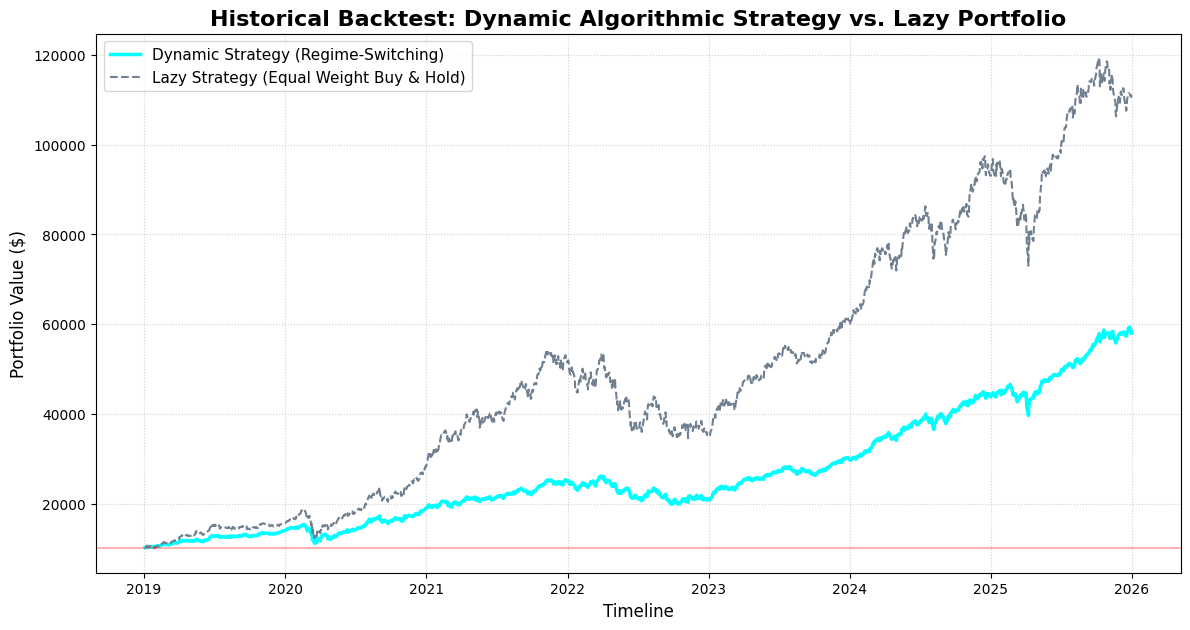

FINAL RETURNS OF OUR DYNAMIC SWITCHING OF PORTOFOLIO DEPENDING ON THE MARKET REGIME
Final Value of Dynamic Strategy: $58,028.40
Final Value of Lazy Portfolio:   $110,286.07


In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Dynamic Regime-Switching Backtest\n")

# 1. Set the initial investment amount and basic variables
initial_investment = 10000
asset_returns = portfolio_data.drop(columns=['Market_Regime'])
num_assets = len(asset_returns.columns)

# 2. Build the Dynamic Daily Trading Calendar
# Create an empty spreadsheet the exact size of our historical data
daily_weights = pd.DataFrame(index=portfolio_data.index, columns=asset_returns.columns)

# If it's a Bull market, apply the Bull Max Sharpe weights. If Bear, apply Bear weights.
daily_weights.loc[portfolio_data['Market_Regime'] == 1] = bull_ms_weights
daily_weights.loc[portfolio_data['Market_Regime'] == -1] = bear_mv_weights

daily_weights = daily_weights.shift(1).dropna()     # You only know today's closing regime at the end of the day. You use it to invest for tomorrow.

# Align our returns data to match the shifted timeline
aligned_returns = asset_returns.loc[daily_weights.index]

# 3. Calculate the daily returns for the Dynamic Strategy
# We multiply each day's actual return by whatever the algorithmic weights were on that specific day
dynamic_daily_returns = (aligned_returns * daily_weights.values).sum(axis=1)

# 4. Calculate the daily returns for an Equal Weight Portfolio (The Benchmark)
equal_weights = np.repeat(1/num_assets, num_assets)
equal_daily_returns = (aligned_returns * equal_weights).sum(axis=1)

# 5. Calculate the cumulative growth of $10,000 over the years
dynamic_growth = initial_investment * (1 + dynamic_daily_returns).cumprod()
equal_growth = initial_investment * (1 + equal_daily_returns).cumprod()

# 6. Plot the Equity Curves

plt.figure(figsize=(14, 7))

# Draw the Dynamic Strategy line in a vibrant cyan
plt.plot(dynamic_growth.index, dynamic_growth,
         label='Dynamic Strategy (Regime-Switching)', color='cyan', linewidth=2.5)

# Draw the Equal Weight line in slategray dashes
plt.plot(equal_growth.index, equal_growth,
         label='Lazy Strategy (Equal Weight Buy & Hold)', color='slategray', linewidth=1.5, linestyle='--')

# Chart formatting
plt.title('Historical Backtest: Dynamic Algorithmic Strategy vs. Lazy Portfolio', fontsize=16, fontweight='bold')
plt.ylabel('Portfolio Value ($)', fontsize=12)
plt.xlabel('Timeline', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# Highlight the starting line
plt.axhline(y=initial_investment, color='red', linestyle='-', alpha=0.3)

plt.show()

# 7. Print the final scoreboard

print("FINAL RETURNS OF OUR DYNAMIC SWITCHING OF PORTOFOLIO DEPENDING ON THE MARKET REGIME")
print(f"Final Value of Dynamic Strategy: ${dynamic_growth.iloc[-1]:,.2f}")
print(f"Final Value of Lazy Portfolio:   ${equal_growth.iloc[-1]:,.2f}")

Implementing the Machine Learning HRP Engine
Step 1: Building the Hierarchical Tree


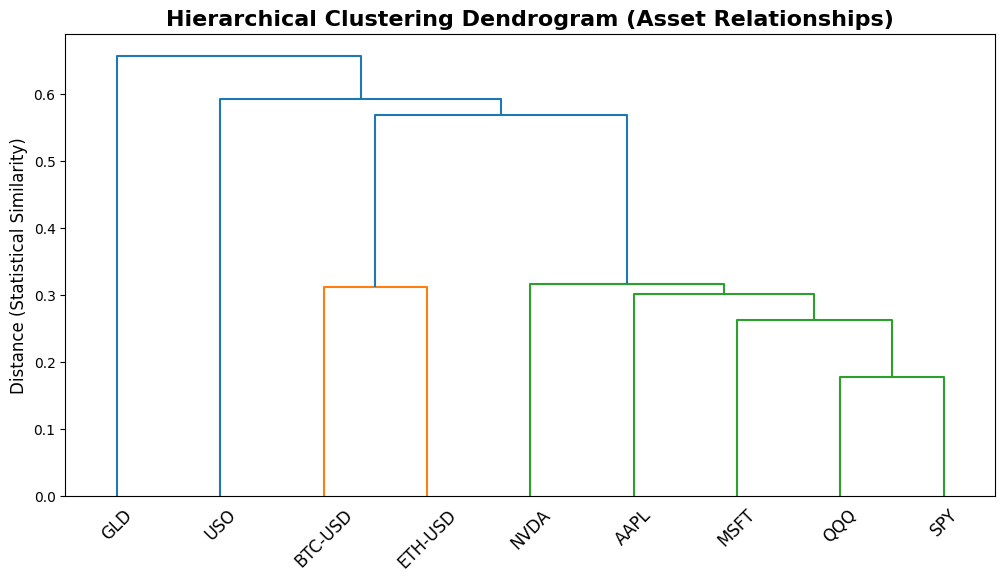


Step 2: Reordering the assets logically
Old alphabetic order: ['AAPL', 'BTC-USD', 'ETH-USD', 'GLD', 'MSFT', 'NVDA', 'QQQ', 'SPY', 'USO']
New clustered order: ['GLD', 'USO', 'BTC-USD', 'ETH-USD', 'NVDA', 'AAPL', 'MSFT', 'QQQ', 'SPY']

Step 3: Calculating Risk Parity Top-Down
 FINAL PORTFOLIO DERIVED USING HRP
         HRP Weight (%)
AAPL               7.00
BTC-USD            2.18
ETH-USD            1.28
GLD               57.37
MSFT               7.51
NVDA               2.54
QQQ                5.37
SPY                8.05
USO                8.70


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

print("Implementing the Machine Learning HRP Engine")

# 1. Isolate the asset returns (ignoring regimes for this global structural test)
asset_returns = portfolio_data.drop(columns=['Market_Regime'])

# 2. Calculate Annualized Correlation and Covariance
cov_matrix = asset_returns.cov() * 252
corr_matrix = asset_returns.corr()

# STEP 1: HIERARCHICAL CLUSTERING & DENDROGRAM
print("Step 1: Building the Hierarchical Tree")

#  Converting the correlations into Distances for the HRP model to assosciate them with each other
distances = np.sqrt(0.5 * (1 - corr_matrix))

# Use SciPy linkage to link the close distances together
condensed_dist = distances.values[np.triu_indices(len(corr_matrix), 1)]
linkage_matrix = sch.linkage(condensed_dist, method='single')

# Plot the resulting Dendrogram
plt.figure(figsize=(12, 6))
dendro = sch.dendrogram(linkage_matrix, labels=corr_matrix.columns, leaf_rotation=45, leaf_font_size=12)
plt.title("Hierarchical Clustering Dendrogram (Asset Relationships)", fontsize=16, fontweight='bold')
plt.ylabel("Distance (Statistical Similarity)", fontsize=12)
plt.grid(False)
plt.show()


# STEP 2: QUASI-DIAGONALIZATION (Reordering the Matrix)
print("\nStep 2: Reordering the assets logically")

# Extract the exact order of the assets as they appear from left to right on the Dendrogram
sorted_indices = dendro['leaves']
sorted_assets = corr_matrix.columns[sorted_indices].tolist()

print(f"Old alphabetic order: {corr_matrix.columns.tolist()}")
print(f"New clustered order: {sorted_assets}")


# STEP 3: RECURSIVE BISECTION (Allocating risk)
print("\nStep 3: Calculating Risk Parity Top-Down")

# A helper function to calculate the exact risk (variance) of a sub-cluster
def get_cluster_variance(cov, weights):
    return np.dot(weights.T, np.dot(cov, weights))

# The core recursive ML algorithm
def get_hrp_weights(cov_matrix, sorted_indices):
    # Initialize all weights to 1.0 (100%), we will chop this down recursively
    weights = pd.Series(1.0, index=sorted_indices)

    # Start with all assets in one giant cluster
    clusters = [sorted_indices]

    while len(clusters) > 0:
        clusters_to_bisect = [c for c in clusters if len(c) > 1]
        clusters = [] # Reset clusters for the next level down the tree
        for cluster in clusters_to_bisect:
            # Split the cluster cleanly down the middle based on the Dendrogram order
            midpoint = len(cluster) // 2
            left_branch = cluster[:midpoint]
            right_branch = cluster[midpoint:]

            # Isolate the covariance matrix for just the left side
            cov_left = cov_matrix.iloc[left_branch, left_branch]
            inv_var_left = 1.0 / np.diag(cov_left)
            weight_left = inv_var_left / inv_var_left.sum()
            var_left = get_cluster_variance(cov_left, weight_left)

            # Isolate the covariance matrix for just the right side
            cov_right = cov_matrix.iloc[right_branch, right_branch]
            inv_var_right = 1.0 / np.diag(cov_right)
            weight_right = inv_var_right / inv_var_right.sum()
            var_right = get_cluster_variance(cov_right, weight_right)

            # The Risk Parity Calculation:
            # If the left side is super volatile, give it less capital. If the right is safe, give it more.
            alpha_left = 1.0 - (var_left / (var_left + var_right))
            alpha_right = 1.0 - alpha_left

            # Multiply the assigned capital down into the actual asset weights
            weights[left_branch] *= alpha_left
            weights[right_branch] *= alpha_right

            # Add the sub-branches back to be split again until we reach individual assets
            clusters.extend([left_branch, right_branch])


    return weights

# Execute the recursive bisection
hrp_weights = get_hrp_weights(cov_matrix, sorted_indices)

# Map the final weights to their actual ticker names
hrp_weights.index = sorted_assets
hrp_portfolio = pd.DataFrame({'HRP Weight (%)': hrp_weights * 100}).round(2)

# Sort alphabetically so we can easily read the final recipe
hrp_portfolio = hrp_portfolio.sort_index()

print(" FINAL PORTFOLIO DERIVED USING HRP")
print(hrp_portfolio)

Running Historical Backtest: HRP Portfolio vs Equal Weight Portfolio

Assuming intital investment as $10000



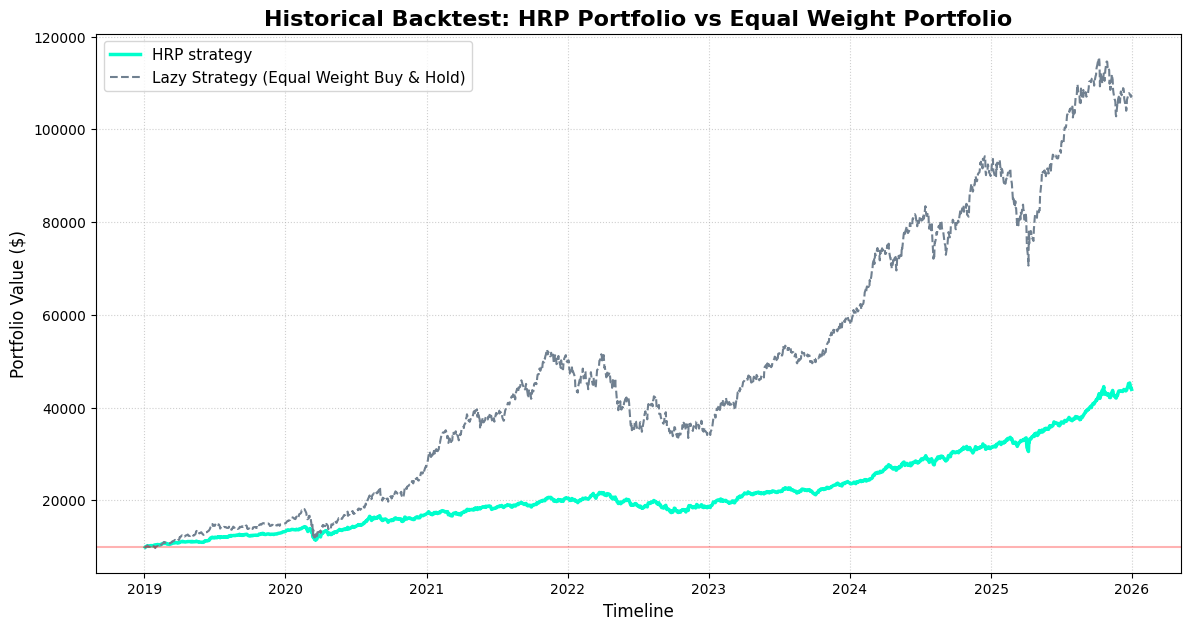

  FINAL BACKTEST RESULTS (HRP vs EQUAL)  
Final Value of HRP Portfolio:   $43,924.91
Final Value of Lazy Portfolio:  $106,618.31


In [20]:
import matplotlib.pyplot as plt
import numpy as np

print("Running Historical Backtest: HRP Portfolio vs Equal Weight Portfolio\n")

#  Setup the initial investment
initial_investment = 10000
print("Assuming intital investment as $10000\n")
num_assets = len(asset_returns.columns)

# We convert them back to decimals (0.0 to 1.0) and align them with the exact columns in asset_returns.
aligned_hrp_weights = (hrp_portfolio['HRP Weight (%)'] / 100).loc[asset_returns.columns]

# Calculate Daily Returns
# Multiply each day's return by the respective portfolio weight
hrp_daily_returns = (asset_returns * aligned_hrp_weights).sum(axis=1)

equal_weights = np.repeat(1/num_assets, num_assets)
equal_daily_returns = (asset_returns * equal_weights).sum(axis=1)

# Calculate Cumulative Growth
# .cumprod() applies daily compound interest over the entire timeline
hrp_growth = initial_investment * (1 + hrp_daily_returns).cumprod()
equal_growth = initial_investment * (1 + equal_daily_returns).cumprod()


# Plot the HRP Strategy line
plt.figure(figsize=(14, 7))
plt.plot(hrp_growth.index, hrp_growth, label='HRP strategy', color='#00ffcc', linewidth=2.5)

# Draw the Equal Weight line
plt.plot(equal_growth.index, equal_growth,
         label='Lazy Strategy (Equal Weight Buy & Hold)', color='slategray', linewidth=1.5, linestyle='--')
plt.title('Historical Backtest: HRP Portfolio vs Equal Weight Portfolio', fontsize=16, fontweight='bold')
plt.ylabel('Portfolio Value ($)', fontsize=12)
plt.xlabel('Timeline', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.axhline(y=initial_investment, color='red', linestyle='-', alpha=0.3)

plt.show()

print("  FINAL BACKTEST RESULTS (HRP vs EQUAL)  ")
print(f"Final Value of HRP Portfolio:   ${hrp_growth.iloc[-1]:,.2f}")
print(f"Final Value of Lazy Portfolio:  ${equal_growth.iloc[-1]:,.2f}")

ANNUALIZED PERFORMANCE (CAGR)
HRP Portfolio Annualized Return: 23.62%
ANNUALIZED SHARPE RATIO
HRP Portfolio Sharpe Ratio: 1.31


MAX DRAWDOWN
HRP Max Drawdown:    -20.06%
Equal Max Drawdown:  -36.37%


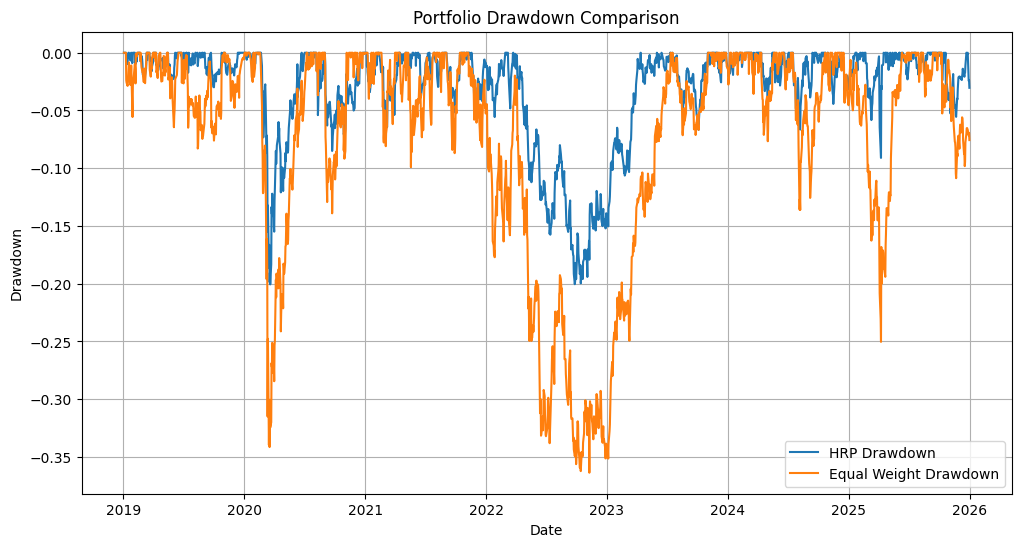

In [21]:
# 7. Calculate Annualized Returns
aligned_hrp_weights = (hrp_portfolio['HRP Weight (%)'] / 100).loc[asset_returns.columns]

hrp_daily_returns = (asset_returns * aligned_hrp_weights).sum(axis=1)

trading_days = len(hrp_daily_returns)
years = trading_days / 252

hrp_final = hrp_growth.iloc[-1]
equal_final = equal_growth.iloc[-1]

hrp_cagr = (hrp_final / initial_investment) ** (1 / years) - 1
equal_cagr = (equal_final / initial_investment) ** (1 / years) - 1

print("ANNUALIZED PERFORMANCE (CAGR)")
print(f"HRP Portfolio Annualized Return: {hrp_cagr*100:.2f}%")

## Calculate Sharpe Ratio
# Convert weights to numpy array
weights = hrp_weights.values
portfolio_returns = asset_returns.dot(weights)

# Annualized Sharpe Ratio
sharpe_ratio = np.sqrt(252) * portfolio_returns.mean() / portfolio_returns.std()
print("ANNUALIZED SHARPE RATIO")
print(f"HRP Portfolio Sharpe Ratio: {sharpe_ratio:.2f}")


# Drawdown for HRP Portfolio
hrp_running_max = hrp_growth.cummax()      # running peak value
hrp_drawdown = (hrp_growth - hrp_running_max) / hrp_running_max
hrp_max_drawdown = hrp_drawdown.min()

# Drawdown for Equal Weight Portfolio
equal_running_max = equal_growth.cummax()
equal_drawdown = (equal_growth - equal_running_max) / equal_running_max
equal_max_drawdown = equal_drawdown.min()

print("\n")


print("MAX DRAWDOWN")
print(f"HRP Max Drawdown:    {hrp_max_drawdown*100:.2f}%")
print(f"Equal Max Drawdown:  {equal_max_drawdown*100:.2f}%")

plt.figure(figsize=(12,6))

plt.plot(hrp_drawdown, label="HRP Drawdown")
plt.plot(equal_drawdown, label="Equal Weight Drawdown")

plt.title("Portfolio Drawdown Comparison")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()


## Conclusion: Strategic Comparison of Allocation Models

Throughout this project, we successfully engineered and backtested two fundamentally different approaches to quantitative asset allocation. While both aim to protect capital and generate yield, their mathematical engines and underlying market philosophies are entirely distinct.

### The Active Approach: Dynamic Regime-Switching
The Dynamic Regime-Switching model represents an active, tactical approach to portfolio management. Operating much like a hedge fund strategy, it attempts to time the market by shifting allocations based on the prevailing economic weather. Its mathematical engine relies on traditional Mean-Variance Optimization, using historical returns and covariance matrix inversion to maximize risk-adjusted performance. Risk is managed temporally; the algorithm aggressively captures upside during expansionary periods and relies on a smoothed mathematical signal to flee into safe-haven assets only after a crash is confirmed. While this approach offers high potential returns, it requires high portfolio turnover, suffers from frictional trading costs, and is highly vulnerable to historical bias if future asset correlations suddenly deviate from past norms.

### The Passive Approach: Hierarchical Risk Parity (HRP)

In stark contrast, the Hierarchical Risk Parity (HRP) strategy takes a passive, structural approach typical of large institutional endowments. It operates on the philosophy that the market cannot be timed. Instead of relying on the fragile math of historical returns and matrix inversion, HRP uses unsupervised machine learning to map the structural "family tree" of asset relationships. It manages risk spatially by physically separating highly correlated assets into distinct branches, ensuring that contagion in one sector cannot wipe out the entire portfolio. This creates a robust, "all-weather" fortress that naturally prevents severe drawdowns and requires very low turnover. The necessary trade-off, however, is that by heavily restricting volatile, high-growth assets, HRP will mathematically underperform more aggressive strategies during prolonged, multi-year bull markets.


### The Final Verdict
Ultimately, the choice between these models depends on the investor's core objective. The **Dynamic Regime-Switching** strategy is ideally suited for algorithmic trading bots and aggressive growth portfolios where the investor is willing to accept higher volatility and transaction fees in pursuit of maximum returns. Conversely, the **HRP** strategy is built for massive pension funds and generational wealth preservation. It is the definitive choice for long-term, risk-averse investors